# K-Means++ clustering na cijelom skupu

Samostalni notebook: pusta **K-Means s k-means++ inicijalizacijom** (k=6, bez labela) na
cijelom skupu znacajki i pokazuje na grafu koliko se dobiveni clusteri poklapaju s pravim
klasama (**BIC, CAR, HEAVY, MC, NOISE, TRAM**).

K-means++ bira pocetne centroide pametno: prvi slucajno, svaki sljedeci s vjerojatnoscu
proporcionalnom kvadratu udaljenosti od vec odabranih centroida. Time su pocetni centri
rasprseni po podacima umjesto nagurani na jednom mjestu, pa je clustering stabilniji i
konvergira bolje nego s cisto slucajnom inicijalizacijom.

Znacajke se ucitavaju iz caches (`data/znacajke_cache_6klasa.pkl`); ako on jos ne postoji,
notebook ga sam izgradi - postojeci 4-klasni cache preuzme gotov, a ekstrakcija se vrti
samo za klase koje fale.

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import signal
from scipy.stats import linregress

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

base_path = '../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC', 'NOISE', 'TRAM']

# Fiksne boje po klasi i po clusteru (uvijek isti redoslijed, nikad ciklicki)
PALETTE = {
    'BIC':   '#2a78d6',  # plava
    'CAR':   '#008300',  # zelena
    'HEAVY': '#e87ba4',  # magenta
    'MC':    '#eda100',  # zuta
    'NOISE': '#1baf7a',  # aqua
    'TRAM':  '#eb6834',  # narancasta
}
CLUSTER_COLORS = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834']
SURFACE = '#fcfcfb'
GRID = '#e1e0d9'
MUTED = '#898781'
INK = '#0b0b0b'


def style_ax(ax):
    """Recesivna mreza i osi - podaci u prvom planu, chrome u pozadini."""
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(True, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=8, length=0)

## Pipeline znacajki (identican kao u koji_model_biramo notebookovima)

Treba nam samo ako cache jos ne postoji - inace se ovaj cell samo definira i preskace.

In [2]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y


LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))
    y_win = y * window
    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2
    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope


def bandwidth_low_band(freqs, psd):
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

## Ucitavanje znacajki (s cacheom)

In [3]:
CACHE_6 = '../data/znacajke_cache_6klasa.pkl'
CACHE_4 = '../data/znacajke_cache.pkl'  # stari cache s 4 klase


def extract_class(label):
    folder = os.path.join(base_path, label)
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]
    rows = []
    for i, file in enumerate(files):
        if i % 50 == 0:
            print(f"   {label}: {i}/{len(files)}")
        y, sr = librosa.load(os.path.join(folder, file), sr=None)
        y = y[:sr * 2]  # CLIP_SECONDS = 2
        y = preprocess(y, sr)
        feats = extract_features(y, sr)
        feats['label'] = label
        rows.append(feats)
    return rows


if os.path.exists(CACHE_6):
    df = pd.read_pickle(CACHE_6)
    print(f"Znacajke ucitane iz cachea: {CACHE_6} ({len(df)} uzoraka)")
else:
    parts = []
    have = []
    if os.path.exists(CACHE_4):
        df4 = pd.read_pickle(CACHE_4)
        parts.append(df4)
        have = list(df4['label'].unique())
        print(f"Preuzeto iz starog cachea: {have} ({len(df4)} uzoraka)")

    missing = [c for c in classes if c not in have]
    print(f"Ekstrakcija za: {missing}")
    for label in missing:
        parts.append(pd.DataFrame(extract_class(label)))

    df = pd.concat(parts, ignore_index=True)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]
    df.to_pickle(CACHE_6)
    print(f"Znacajke spremljene u cache: {CACHE_6}")

print("\nBroj uzoraka po klasi:")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

# Standardizacija je nuzna: K-Means radi na euklidskim udaljenostima, a znacajke su na
# potpuno razlicitim skalama (rms ~0.01 vs spectral_centroid ~1000).
X_scaled = StandardScaler().fit_transform(X)

Znacajke ucitane iz cachea: ../data/znacajke_cache_6klasa.pkl (13668 uzoraka)

Broj uzoraka po klasi:
label
CAR      9348
NOISE    1577
HEAVY    1190
TRAM      700
MC        519
BIC       334
Name: count, dtype: int64


## K-Means++ na cijelom skupu

Clustering se radi u punom 25-dimenzionalnom prostoru znacajki (ne na PCA projekciji!).
Uz clustere racunamo:

- **Adjusted Rand Index (ARI)**: 1.0 = clusteri savrseno odgovaraju klasama, ~0 = slucajno
- **Silhouette score**: koliko su clusteri kompaktni i medjusobno odvojeni (bez obzira na klase)

In [4]:
# k-means++ inicijalizacija, 10 nezavisnih pokretanja (uzima se najbolje po inerciji),
# fit na CIJELOM standardiziranom skupu
km = KMeans(n_clusters=len(classes), init='k-means++', n_init=10, random_state=42)
cluster_ids = km.fit_predict(X_scaled)

ari = adjusted_rand_score(y, cluster_ids)
sil = silhouette_score(X_scaled, cluster_ids, sample_size=3000, random_state=42)
print(f"Adjusted Rand Index (cluster vs klasa): {ari:.3f}")
print(f"Silhouette score clusteringa:           {sil:.3f}")

print("\nVelicine clustera:")
print(pd.Series(cluster_ids).value_counts().sort_index())

Adjusted Rand Index (cluster vs klasa): 0.085
Silhouette score clusteringa:           0.124

Velicine clustera:
0    1978
1    4682
2    2470
3     396
4    3159
5     983
Name: count, dtype: int64


## Graf: prave klase vs. k-means++ clusteri

Za prikaz projiciramo podatke (i centroide, istom transformacijom) u 2D PCA ravninu.
Lijevo su prave klase, desno k-means++ clusteri s centroidima (X markeri) - ako se
lijeva i desna slika strukturno poklapaju, prirodne grupe u podacima prate nase klase.

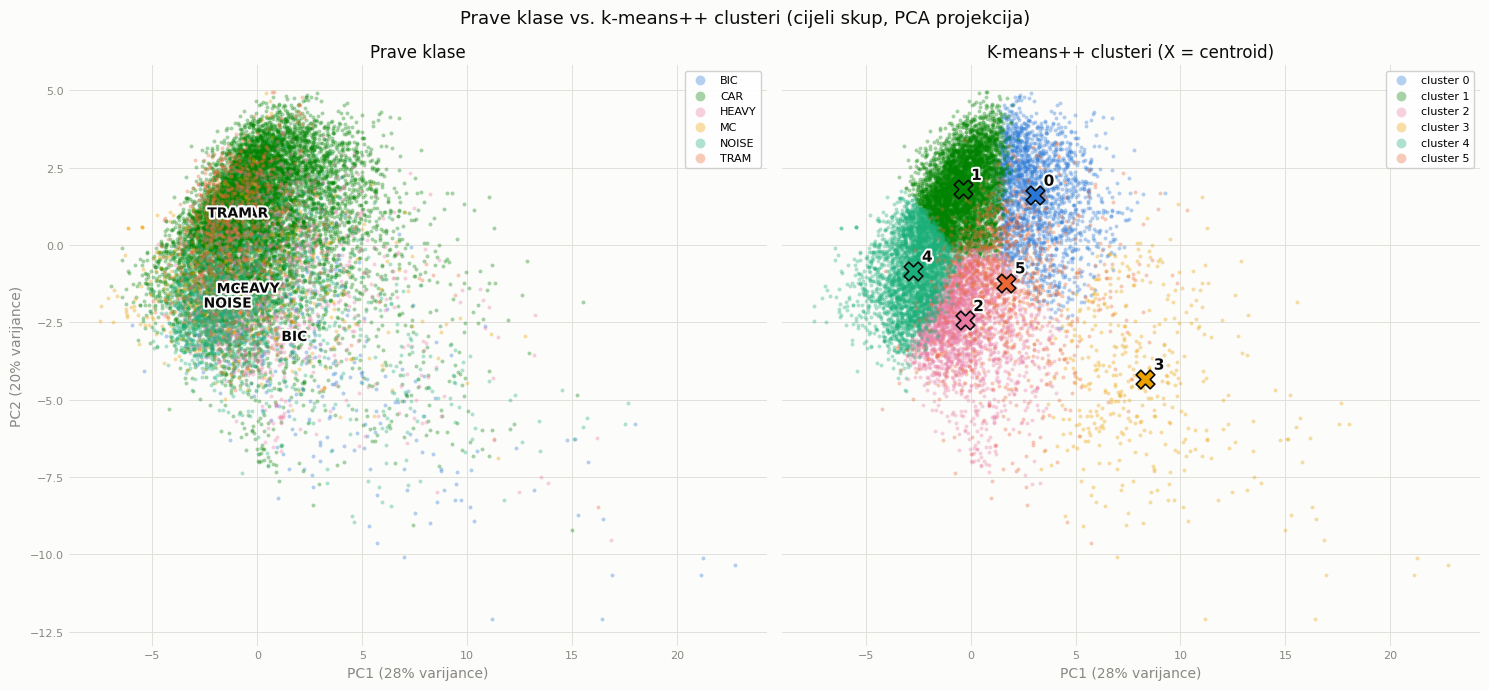

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_

# Centroide (u 25D prostoru znacajki) projiciramo istom PCA transformacijom kao tocke
centroids_pca = pca.transform(km.cluster_centers_)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 7), facecolor=SURFACE,
                                 sharex=True, sharey=True)

# Lijevo: prave klase
for cls in classes:
    m = (y == cls).to_numpy()
    ax_l.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.35, linewidths=0,
                 color=PALETTE[cls], label=cls)
for cls in classes:
    m = (y == cls).to_numpy()
    ax_l.annotate(cls, (np.median(X_pca[m, 0]), np.median(X_pca[m, 1])),
                  fontsize=10, fontweight='bold', color=INK, ha='center',
                  path_effects=[pe.withStroke(linewidth=3, foreground=SURFACE)])
ax_l.set_title('Prave klase', color=INK, fontsize=12)

# Desno: k-means++ clusteri + centroidi
for c in range(km.n_clusters):
    m = cluster_ids == c
    ax_r.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.35, linewidths=0,
                 color=CLUSTER_COLORS[c], label=f'cluster {c}')
for c in range(km.n_clusters):
    ax_r.scatter(*centroids_pca[c], marker='X', s=180, color=CLUSTER_COLORS[c],
                 edgecolors=INK, linewidths=1.2, zorder=5)
    ax_r.annotate(str(c), centroids_pca[c], fontsize=11, fontweight='bold', color=INK,
                  ha='center', va='center', xytext=(10, 10), textcoords='offset points',
                  path_effects=[pe.withStroke(linewidth=3, foreground=SURFACE)])
ax_r.set_title('K-means++ clusteri (X = centroid)', color=INK, fontsize=12)

for ax in (ax_l, ax_r):
    style_ax(ax)
    ax.set_xlabel(f'PC1 ({var[0]:.0%} varijance)', color=MUTED)
    ax.legend(markerscale=2.5, framealpha=0.9, fontsize=8, loc='best')
ax_l.set_ylabel(f'PC2 ({var[1]:.0%} varijance)', color=MUTED)

fig.suptitle('Prave klase vs. k-means++ clusteri (cijeli skup, PCA projekcija)',
             color=INK, fontsize=13)
plt.tight_layout()
plt.show()

## Heatmapa: gdje zavrsava koja klasa?

Svaki stupac (klasa) normaliziran je na 100% - vidi se u koje se clustere svaka klasa
raspada. Klasa koja "zivi" u jednom clusteru je kompaktna; klasa razmazana preko vise
clustera akusticki nije homogena.

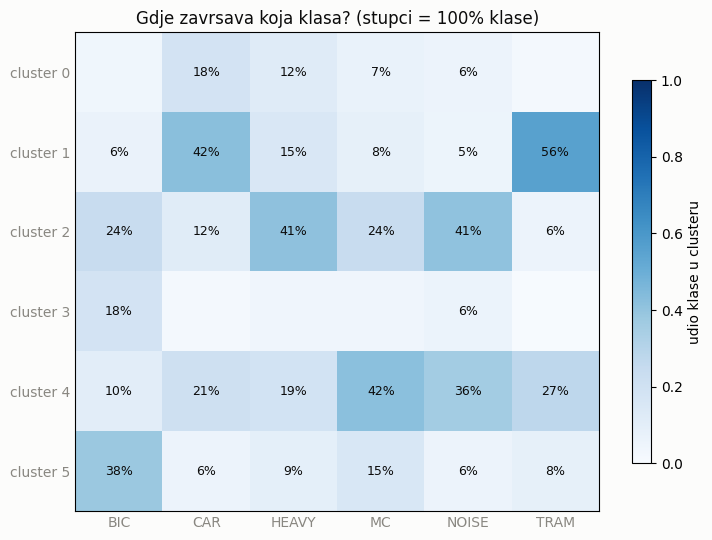

In [6]:
ct = pd.crosstab(cluster_ids, y)
ct = ct[classes]
ct_pct = ct / ct.sum(axis=0)  # normalizacija po klasi (stupcu)

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=SURFACE)
im = ax.imshow(ct_pct, cmap='Blues', vmin=0, vmax=1, aspect='auto')

for i in range(ct_pct.shape[0]):
    for j in range(ct_pct.shape[1]):
        v = ct_pct.iloc[i, j]
        if v >= 0.05:  # oznacavamo samo znacajne celije, ne svaku
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9,
                    color='white' if v > 0.6 else INK)

ax.set_xticks(range(len(classes)), classes)
ax.set_yticks(range(ct_pct.shape[0]), [f'cluster {c}' for c in ct_pct.index])
ax.tick_params(colors=MUTED, length=0)
ax.set_title('Gdje zavrsava koja klasa? (stupci = 100% klase)', color=INK, fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.8, label='udio klase u clusteru')
plt.tight_layout()
plt.show()

## Bonus: je li 6 uopce "prirodan" broj grupa?

Elbow (inercija) + silhouette za k od 2 do 10. Ako koljeno/maksimum ne padne na k=6,
podaci se prirodno grupiraju u drugaciji broj grupa nego sto imamo klasa - korisno znati
kod tumacenja ARI-ja.

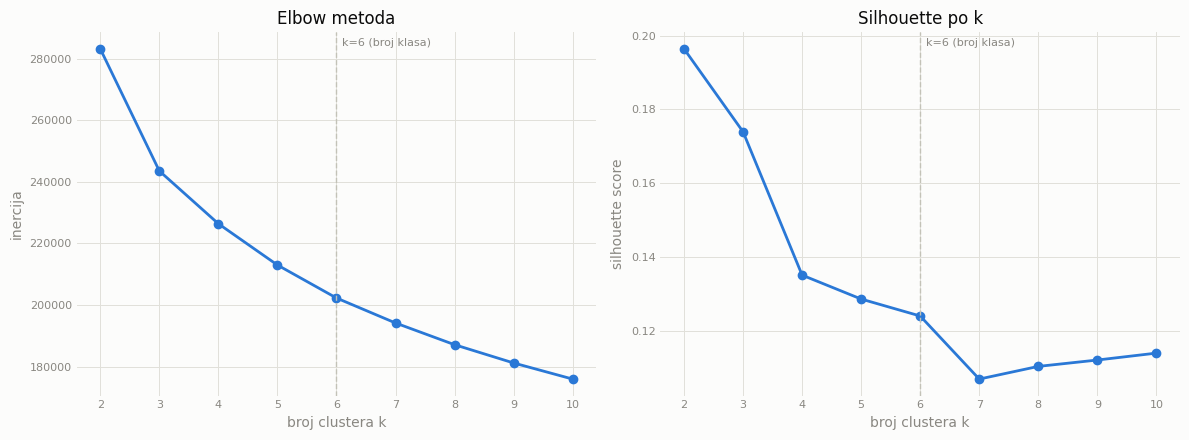

In [7]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km_k = KMeans(n_clusters=k, init='k-means++', n_init=5, random_state=42)
    ids_k = km_k.fit_predict(X_scaled)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(X_scaled, ids_k, sample_size=3000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=SURFACE)

ax1.plot(list(ks), inertias, color='#2a78d6', linewidth=2, marker='o', markersize=6)
ax1.set_xlabel('broj clustera k', color=MUTED)
ax1.set_ylabel('inercija', color=MUTED)
ax1.set_title('Elbow metoda', color=INK, fontsize=12)

ax2.plot(list(ks), sils, color='#2a78d6', linewidth=2, marker='o', markersize=6)
ax2.set_xlabel('broj clustera k', color=MUTED)
ax2.set_ylabel('silhouette score', color=MUTED)
ax2.set_title('Silhouette po k', color=INK, fontsize=12)

for ax in (ax1, ax2):
    style_ax(ax)
    ax.axvline(6, color='#c3c2b7', linewidth=1, linestyle='--')
    ax.annotate('k=6 (broj klasa)', (6, ax.get_ylim()[1]), fontsize=8, color=MUTED,
                ha='left', va='top', xytext=(4, -4), textcoords='offset points')

plt.tight_layout()
plt.show()

## Kako citati rezultate

- **Clusteri prate klase** (desna slika kopira lijevu, visok ARI, svaka klasa u svom
  retku heatmape) - klase su prirodno odvojive vec bez ikakvog nadzora.
- **Clusteri sijeku klase** (npr. jedan cluster pokrije i CAR i MC) - te klase bez labela
  izgledaju kao jedna akusticka grupa; supervizirani model ih moze razdvojiti samo ako
  granica postoji, ali je suptilnija od prirodnog grupiranja.
- **ARI blizu 0 uz vizualno jasne grupe** - prirodno grupiranje postoji, ali ne prati nase
  klase (npr. grupira po glasnoci snimke, a ne po tipu vozila).